In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os


In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

In [ ]:
FILES = [
    'DAM_April_2023.csv', 'DAM_May_2023.csv', 'DAM_June_2023.csv',
    'DAM_July_2023.csv', 'DAM_August_2023.csv', 'DAM_September_2023.csv',
    'DAM_October_2023.csv'
]
DATA_DIR   = '../data/'


In [8]:
def load_dam(files, base_dir):
    frames = []
    for f in files:
        df = pd.read_csv(os.path.join(base_dir, f))
        print(f, df.shape)
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

data = load_dam(FILES, DATA_DIR)

DAM_April_2023.csv (2880, 5)
DAM_May_2023.csv (2976, 5)
DAM_June_2023.csv (2880, 5)
DAM_July_2023.csv (2976, 5)
DAM_August_2023.csv (2976, 5)
DAM_September_2023.csv (2880, 5)
DAM_October_2023.csv (2976, 5)


In [9]:
TEST_START_DATE = '2023-10-01'
HORIZON = 96

In [10]:
def pre_process(df):
    df = df.copy()
    df.columns = ['date', 'time_period', 'buy_mw', 'sell_mw', 'price']
    df['start_time'] = df['time_period'].str.split('-').str[0].str.strip()
    df['datetime'] = pd.to_datetime(
            df['date'].str.strip() + ' ' + df['start_time'],
            format='%d/%m/%Y %H:%M'
        )
    df = df.drop(columns=['date', 'time_period', 'start_time'])
    df = df.drop_duplicates('datetime').sort_values('datetime')

    # ensure continuous time series
    df = df.set_index('datetime')
    df = df.asfreq('15min')
    df['price'] = df['price'].interpolate(method = 'time')
    df = df.dropna()
    return df

In [25]:
df = pre_process(data)

In [26]:
ts = df['price']

In [27]:
train = df[df.index < TEST_START_DATE]
test  = df[df.index >= TEST_START_DATE]

train['price_log'] = np.log1p(train['price'])
test['price_log']  = np.log1p(test['price'])

train.shape, test.shape

((17568, 4), (2976, 4))

### EDA

In [28]:
train['price_log_diff'] = train['price_log'].diff()
train = train.dropna()

In [18]:
def plot_acf_pacf(data, col):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # 2. Plot ACF on the top axis (ax1)
    plot_acf(data[col], ax=ax1, lags=40)
    ax1.set_xticks(np.arange(0, 41, 1))
    ax1.set_title("Autocorrelation (ACF)")

    # 3. Plot PACF on the bottom axis (ax2)
    plot_pacf(data[col], ax=ax2, method='ywm', lags=40)
    ax2.set_xticks(np.arange(0, 41, 1))
    ax2.set_title("Partial Autocorrelation (PACF)")

    # 4. Adjust layout so titles don't overlap
    plt.tight_layout()
    plt.show()

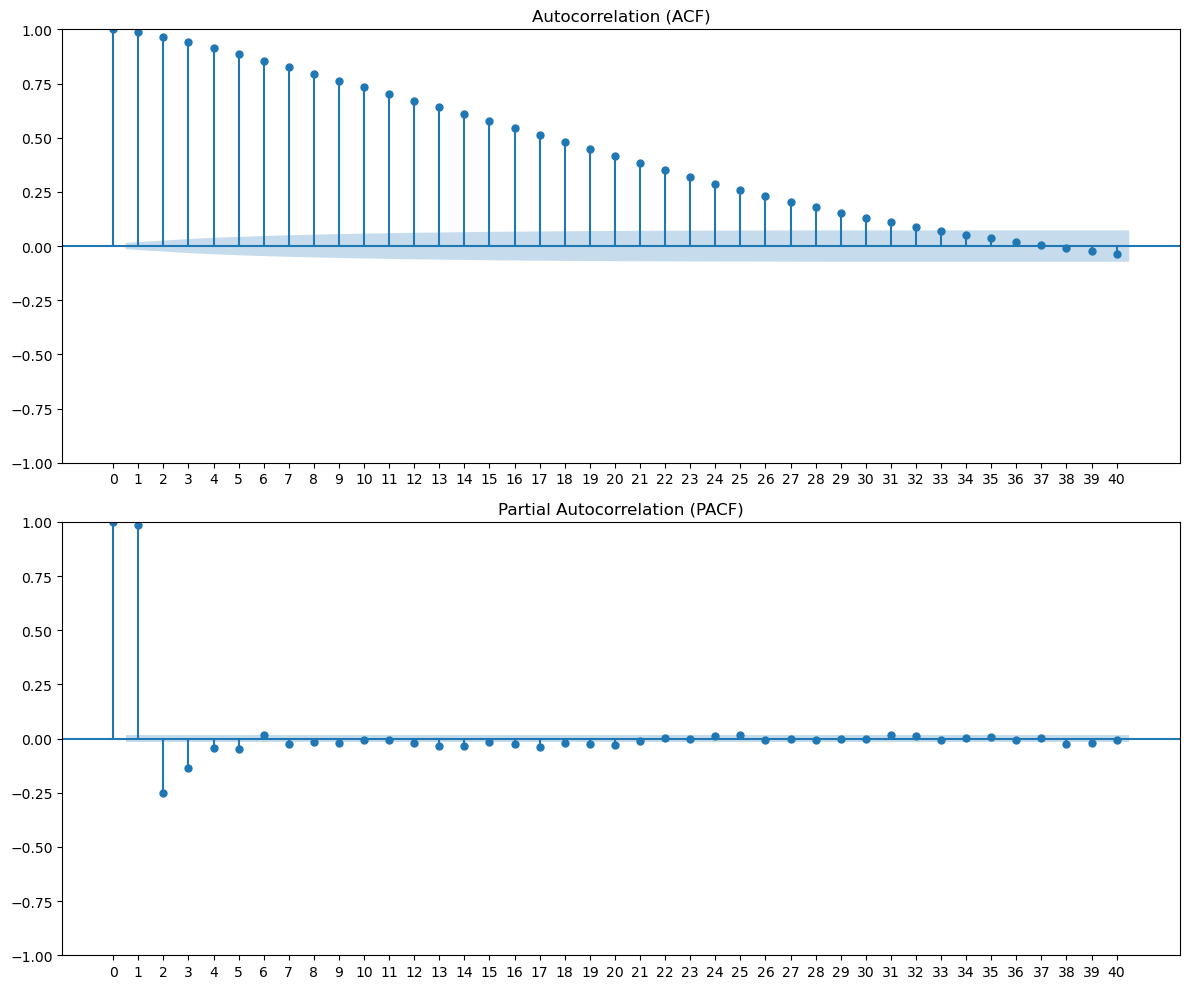

In [29]:
plot_acf_pacf(train, 'price_log')

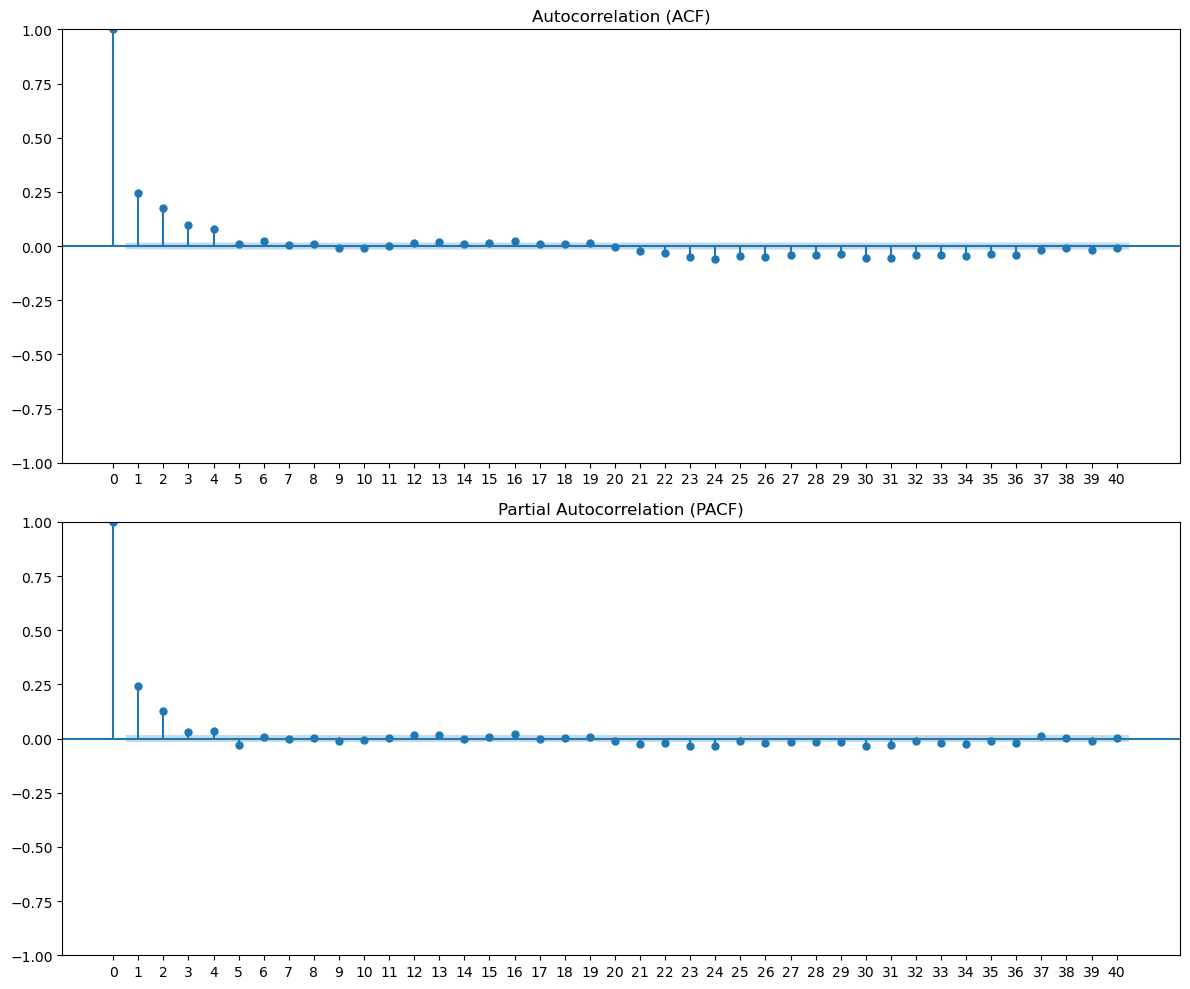

In [30]:
plot_acf_pacf(train, 'price_log_diff')

##### Best order from pacf and acf plots - (2, 1, 4) or (2, 1, 2)

### Data Preparation

In [31]:
train = df[df.index < TEST_START_DATE]
test  = df[df.index >= TEST_START_DATE]

train['price_log'] = np.log1p(train['price'])
test['price_log']  = np.log1p(test['price'])

train.shape, test.shape

((17568, 4), (2976, 4))

In [32]:
train_series = train['price_log']
test_series = test['price_log']    

##### ARIMA

In [33]:
order = (2, 1, 4)
# get unique test days
test_days = pd.date_range(
    start=test_series.index.min().normalize(),
    end=test_series.index.max().normalize(),
    freq='D'
)
    
preds = []
history = train_series.copy()

for day in test_days:
    
    day_start = day
    day_end = day + pd.Timedelta(hours=23, minutes=45)
    
    #Train on history
    model = ARIMA(history, order=order)
    model_fit = model.fit()
    
    # Forecast full day (96 points)
    forecast = model_fit.forecast(steps=HORIZON)
    preds.extend(forecast.values)
    
    # Get actual data
    actual = test_series[day_start:day_end]
    
    # sanity check
    if len(actual) != HORIZON:
        print(f"Warning: {day.date()} has {len(actual)} points (expected 96)")
    
    # update history-
    history = pd.concat([history, actual])

# inverse_log
pred_arima = np.array(preds[:len(test_series)])
pred_arima = np.expm1(pred_arima)

In [34]:
test['y_pred_arima'] = pred_arima

##### SARIMA

In [54]:
test_days = pd.date_range(
        start=test_series.index.min().normalize(),
        end=test_series.index.max().normalize(),
        freq='D')
    
preds = []

# Initial fit - only once
model = SARIMAX(
    train_series[-96*30:],
    order=(1,1,1),
    seasonal_order=(1,0,1,96),
    enforce_stationarity=False,
    enforce_invertibility=False
)
model_fit = model.fit(disp=False)

for day in test_days:
    
    day_start = day
    day_end = day + pd.Timedelta(hours=23, minutes=45)
    
    # Forecast
    forecast = model_fit.forecast(steps=HORIZON)
    preds.extend(forecast.values)
    
    # Get Actual Data
    actual = test_series[day_start:day_end]
    
    # Update model - no refit
    model_fit = model_fit.append(actual, refit=False)

pred_sarima = np.array(preds[:len(test_series)])
pred_sarima = np.expm1(pred_sarima)

In [56]:
test['y_pred_sarima'] = pred_sarima

### Prophet

In [36]:
from prophet import Prophet

In [37]:
def prepare_prophet_df(df):
    """
    Prophet requires:
    ds → datetime
    y → target
    """
    prophet_df = df.reset_index()[['datetime', 'price']]
    prophet_df.columns = ['ds', 'y']
    return prophet_df


In [38]:
def train_prophet_model(train_df, test_df):
    
    HORIZON = 96
    
    # Convert to Prophet format
    train_p = prepare_prophet_df(train_df)
    test_p  = prepare_prophet_df(test_df)
    
    test_days = pd.date_range(
        start=test_p['ds'].min().normalize(),
        end=test_p['ds'].max().normalize(),
        freq='D'
    )
    
    preds = []
    history = train_p.copy()
    
    for day in test_days:
        print(f"Forecasting {day.date()}")
        
        # Fit model
        model = Prophet(
            daily_seasonality=True,
            weekly_seasonality=True,
            yearly_seasonality=False
        )
        
        model.fit(history)
        
        # Create future steps (96)
        future = model.make_future_dataframe(
            periods=HORIZON,
            freq='15min',
            include_history=False
        )
        
        # Forecast
        forecast = model.predict(future)
        
        preds.extend(forecast['yhat'].values)
        
        # Get actuals
        day_start = day
        day_end = day + pd.Timedelta(hours=23, minutes=45)
        
        actual = test_p[(test_p['ds'] >= day_start) & (test_p['ds'] <= day_end)]
        
        # update history
        history = pd.concat([history, actual])
    
    preds = np.array(preds[:len(test_p)])
    
    return preds

In [39]:
preds_prophet = train_prophet_model(train, test)

Forecasting 2023-10-01


13:02:52 - cmdstanpy - INFO - Chain [1] start processing
13:03:04 - cmdstanpy - INFO - Chain [1] done processing


Forecasting 2023-10-02


13:03:06 - cmdstanpy - INFO - Chain [1] start processing
13:03:18 - cmdstanpy - INFO - Chain [1] done processing


Forecasting 2023-10-03


...

13:11:09 - cmdstanpy - INFO - Chain [1] start processing
13:11:19 - cmdstanpy - INFO - Chain [1] done processing


Forecasting 2023-10-30


13:11:21 - cmdstanpy - INFO - Chain [1] start processing
13:11:44 - cmdstanpy - INFO - Chain [1] done processing


Forecasting 2023-10-31


13:11:47 - cmdstanpy - INFO - Chain [1] start processing
13:12:11 - cmdstanpy - INFO - Chain [1] done processing


In [40]:
test['y_pred_prophet'] = preds_prophet

### Evaluate

In [42]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

def evaluate(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask])) / (y_true[mask]+1e-6)) * 100
    print(f'[{label}]  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%')
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

In [43]:
evaluate(test['price'].values, pred_arima, 'ARIMA -> (2,1,4)')

[ARIMA -> (2,1,4)]  MAE=1591.43  RMSE=2710.51  MAPE=36.06%


{'MAE': 1591.431622144206,
 'RMSE': np.float64(2710.5107752759623),
 'MAPE': np.float64(36.05643165770615)}

In [55]:
evaluate(test['price'].values, pred_sarima, 'SARIMA')

[SARIMA]  MAE=1364.99  RMSE=1946.67  MAPE=24.98%


{'MAE': 1364.993897930575,
 'RMSE': np.float64(1946.6735001214781),
 'MAPE': np.float64(24.983017104429862)}

In [44]:
evaluate(test['price'].values, preds_prophet, 'prophet')

[prophet]  MAE=2844.83  RMSE=3419.83  MAPE=50.07%


{'MAE': 2844.831298267035,
 'RMSE': np.float64(3419.8304576256273),
 'MAPE': np.float64(50.06655132283385)}

In [ ]:
test[['datetime', 'price','y_pred_arima','y_pred_sarima', 'y_pred_prophet']].head()